# Exercise 7: Conditional INNs and Disentanglement

Generative AI and Visual Synthesis, SoSe 2026

| Task | Topic | Points |
|---|---|---:|
| 1 | Formal warm-up: ambiguous inverse maps | 7 |
| 2 | Interpreting autoencoder latents | 10 |
| 3 | Conditional normalizing flow on colorized digits | 23 |

Complete all `TODO` sections and keep the requested plots/metrics visible before exporting the notebook as PDF.

In [1]:
# Given: imports and setup
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [2]:
# Given: helpers

def one_hot(labels, num_classes=10):
    labels = np.asarray(labels, dtype=np.int64)
    out = np.zeros((len(labels), num_classes), dtype=np.float32)
    out[np.arange(len(labels)), labels] = 1.0
    return out


def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=DEVICE)


def plot_color_digit_grid(images, title="", nrow=4, ncol=8):
    images = np.asarray(images)
    if images.ndim == 2:
        images = images.reshape(-1, 3, 8, 8)
    fig, axes = plt.subplots(nrow, ncol, figsize=(1.15 * ncol, 1.15 * nrow))
    axes = np.asarray(axes).reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < len(images):
            img = np.moveaxis(images[i], 0, -1)
            ax.imshow(np.clip(img, 0.0, 1.0))
    fig.suptitle(title)
    plt.tight_layout()
    return fig


def plot_embedding(points_2d, colors, title="", colorbar=False):
    fig, ax = plt.subplots(figsize=(5, 4))
    sc = ax.scatter(points_2d[:, 0], points_2d[:, 1], c=colors, s=10, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    if colorbar:
        fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    return fig


def plot_pca_vs_factors(pca_points, factor_digit, factor_color, point_colors):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].scatter(pca_points[:, 0], pca_points[:, 1], c=np.clip(point_colors, 0.0, 1.0), s=12, alpha=0.75)
    axes[0].set_title("Before INN: AE latent PCA")
    axes[0].set_xlabel("PC 1")
    axes[0].set_ylabel("PC 2")

    axes[1].scatter(factor_digit, factor_color, c=np.clip(point_colors, 0.0, 1.0), s=12, alpha=0.75)
    axes[1].set_title("After INN: digit vs color factors")
    axes[1].set_xlabel("digit factor")
    axes[1].set_ylabel("color factor")
    axes[1].set_xticks(range(10))
    axes[1].set_xlim(-0.5, 9.5)
    axes[1].set_ylim(-0.05, 1.05)
    plt.tight_layout()
    return fig


def rgb_to_hue(rgb):
    rgb = np.clip(np.asarray(rgb), 0.0, 1.0)
    r, g, b = rgb[:, 0], rgb[:, 1], rgb[:, 2]
    maxc = rgb.max(axis=1)
    minc = rgb.min(axis=1)
    delta = maxc - minc
    hue = np.zeros(len(rgb), dtype=np.float32)
    mask = delta > 1e-8
    r_mask = mask & (maxc == r)
    g_mask = mask & (maxc == g)
    b_mask = mask & (maxc == b)
    hue[r_mask] = ((g[r_mask] - b[r_mask]) / delta[r_mask]) % 6.0
    hue[g_mask] = ((b[g_mask] - r[g_mask]) / delta[g_mask]) + 2.0
    hue[b_mask] = ((r[b_mask] - g[b_mask]) / delta[b_mask]) + 4.0
    return hue / 6.0


def plot_confusion(cm, title="Confusion matrix"):
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("predicted digit")
    ax.set_ylabel("true digit")
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    for i in range(10):
        for j in range(10):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    return fig

## Task 1: Ambiguous Inverse Maps (7P)

Before we train INNs, we look at the basic reason why an extra latent variable is useful.

Consider a point `x = (x1, x2)` in the plane, with `x != (0, 0)`. Suppose we observe only its radius:

```text
y = sqrt(x1^2 + x2^2)
```

The map `x -> y` is not invertible: many different points have the same radius. A cINN-style representation avoids this information loss by storing an additional variable `z` so that

```text
x <-> (y, z)
```

is invertible. In this toy example, `y` plays the role of the condition and `z` plays the role of the latent/noise variable.


### Task 1 TODO (7P)

**1.1 Deterministic inverse (0.5P)**  
Explain why a deterministic inverse from `y` to `x` cannot recover the original `x`.

**Answer:**  
The forward map `x -> y = sqrt(x1^2 + x2^2)` is *many-to-one*: every point on the circle of radius `y` produces the exact same `y`, so the angular position is thrown away. A deterministic inverse is a *function* `g(y) = x`, which can output only a single point for each `y`. Since infinitely many points `x` share the same `y`, no single-valued function can know which of them was the original. The information needed to distinguish them (the angle) is simply not present in `y`, so any deterministic inverse must be wrong for almost all inputs.

**1.2 MSE prediction and proof (3P)**  
Assume `x` is uniformly distributed on the unit circle, so `y = 1`. Prove which deterministic prediction `x_hat in R^2` minimizes

```text
E[||x - x_hat||_2^2]
```

and compute the minimal expected squared error.

**Answer:**  
The minimizer is the mean of the distribution, `x_hat* = E[x]`, which for a uniform distribution on the unit circle is `(0, 0)` by symmetry. The minimal expected squared error is `1`.

*Proof.* Use the bias–variance decomposition. For any fixed `x_hat`,
```text
E[||x - x_hat||^2] = E[|| (x - E[x]) + (E[x] - x_hat) ||^2]
                   = E[||x - E[x]||^2] + 2 (E[x] - x_hat)^T E[x - E[x]] + ||E[x] - x_hat||^2.
```
The middle term vanishes because `E[x - E[x]] = 0`, leaving
```text
E[||x - x_hat||^2] = E[||x - E[x]||^2] + ||E[x] - x_hat||^2.
```
The first term does not depend on `x_hat`, and the second term is `>= 0` with equality iff `x_hat = E[x]`. Hence the optimal prediction is `x_hat* = E[x]`.

For `x` uniform on the unit circle, write `x = (cos t, sin t)` with `t ~ Uniform(0, 2*pi)`. Then `E[cos t] = E[sin t] = 0`, so `x_hat* = (0, 0)`. The minimal error is
```text
E[||x - 0||^2] = E[x1^2 + x2^2] = E[cos^2 t + sin^2 t] = E[1] = 1.
```
So the minimal expected squared error equals `1`.

**1.3 Add the missing variable (2P)**  
Mathematically define a latent variable that stores the missing information for the circle example. Use `atan2`.

**Answer:**  
`z = atan2(x2, x1)`  — the polar angle of the point, with `z in (-pi, pi]`. Together with the radius `y`, this angle uniquely fixes the point, so `(y, z)` carries exactly the information that was lost when keeping only `y`.

**1.4 Forward and inverse map (1P)**  
Mathematically define the complete forward map `F(x1, x2) = (y, z)` and inverse map `F^{-1}(y, z) = (x1, x2)`.

**Answer:**  
`y = sqrt(x1^2 + x2^2)`  
`z = atan2(x2, x1)`  
`x1 = y * cos(z)`  
`x2 = y * sin(z)`

This is just the conversion between Cartesian and polar coordinates; `F` and `F^{-1}` are exact inverses of each other for `x != (0, 0)`.

**1.5 What is stored in the noise? (0.5P)**  
In this circle example, what information is stored in the latent/noise variable `z`?

**Answer:**  
`z` stores the **angular position (direction / polar angle)** of the point on its circle — precisely the information discarded by the radius map `x -> y`. The condition `y` keeps the radius; the latent `z` keeps the angle, and together they make the map invertible.


## Data: Colorized Digits

Tasks 2 and 3 use the same colorized version of `sklearn.datasets.load_digits`. Each grayscale digit is turned into a small RGB image with a random foreground color on a dark background.

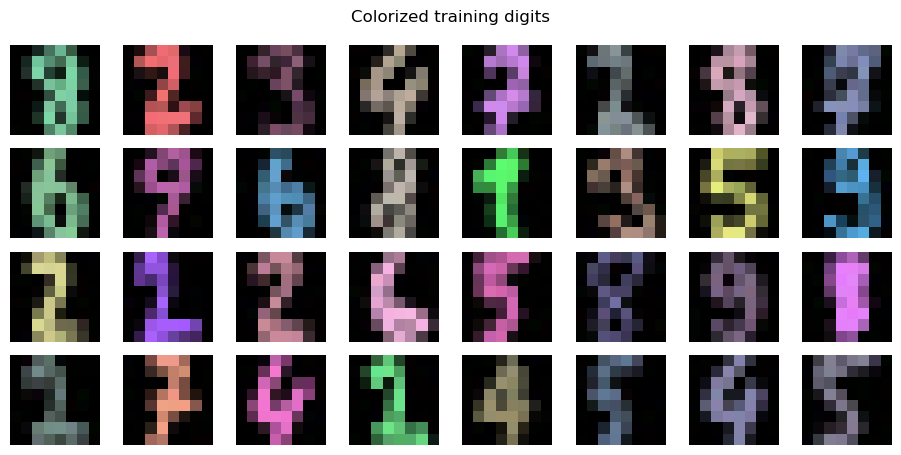

Train images: (1347, 3, 8, 8)
Flattened dimension: 192


In [3]:
# Given: load and colorize the digits dataset

def make_colorized_digits(seed=SEED):
    rng = np.random.default_rng(seed)
    digits = load_digits()
    gray = digits.images.astype(np.float32) / 16.0
    labels = digits.target.astype(np.int64)

    fg = rng.uniform(0.35, 1.0, size=(len(gray), 3, 1, 1)).astype(np.float32)
    bg = np.zeros((len(gray), 3, 1, 1), dtype=np.float32)
    alpha = gray[:, None, :, :]
    color = bg * (1.0 - alpha) + fg * alpha
    color = color + rng.normal(0.0, 0.01, size=color.shape).astype(np.float32)
    color = np.clip(color, 0.0, 1.0)
    fg_rgb = fg[:, :, 0, 0]
    return color, labels, fg_rgb

images_np, labels_np, fg_rgb_np = make_colorized_digits()
X_train_img, X_test_img, y_train_np, y_test_np, fg_train_rgb, fg_test_rgb = train_test_split(
    images_np,
    labels_np,
    fg_rgb_np,
    test_size=0.25,
    random_state=SEED,
    stratify=labels_np,
)

X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_test_flat = X_test_img.reshape(len(X_test_img), -1)

x_train_ae = to_tensor(X_train_flat)
x_test_ae = to_tensor(X_test_flat)
y_train_t = torch.tensor(y_train_np, dtype=torch.long, device=DEVICE)
y_test_t = torch.tensor(y_test_np, dtype=torch.long, device=DEVICE)
fg_train_t = to_tensor(fg_train_rgb)
fg_test_t = to_tensor(fg_test_rgb)

A_train = to_tensor(one_hot(y_train_np))
A_test = to_tensor(one_hot(y_test_np))

DATA_DIM = X_train_flat.shape[1]
COND_DIM = 10
LATENT_DIM = 16

plot_color_digit_grid(X_train_img[:32], "Colorized training digits")
plt.show()
print("Train images:", X_train_img.shape)
print("Flattened dimension:", DATA_DIM)

## Task 2: Interpreting Autoencoder Latents (10P)

This task follows the idea of applying an invertible interpretation network on top of an already learned representation. First train an unconditional autoencoder. Then learn an invertible map on its latent code so that parts of the transformed latent correspond to interpretable factors.

We use three factors:

```text
u = T(z_ae) = [digit factor, color factor, residual factor]
```

The original autoencoder latent `z_ae` must remain recoverable through the inverse map `T^{-1}`.

### Given: Train an Unconditional Autoencoder

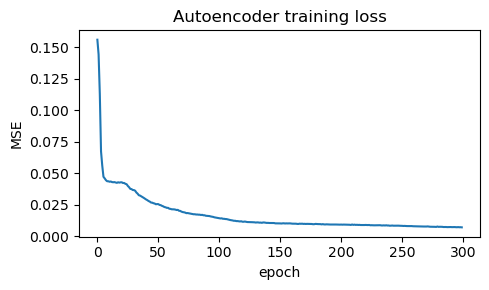

Autoencoder test MSE: 0.008151090703904629


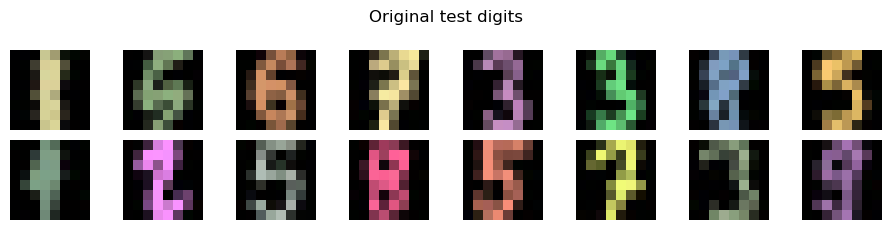

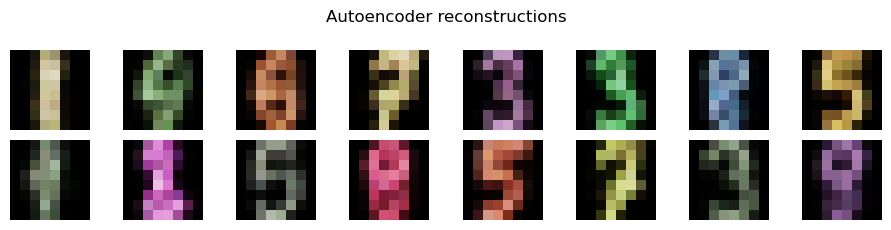

In [4]:
# Given: autoencoder training

class Autoencoder(nn.Module):
    def __init__(self, input_dim=DATA_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, latent_dim))
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 64), nn.ReLU(), nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, input_dim), nn.Sigmoid())
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


ae = Autoencoder().to(DEVICE)


def train_autoencoder(model, x, epochs=300, batch_size=256, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    n = x.shape[0]
    model.train()
    for epoch in range(epochs):
        perm = torch.randperm(n, device=x.device)
        epoch_losses = []
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            batch = x[idx]
            opt.zero_grad()
            x_rec, _ = model(batch)
            loss = F.mse_loss(x_rec, batch)
            loss.backward()
            opt.step()
            epoch_losses.append(float(loss.detach().cpu()))
        losses.append(float(np.mean(epoch_losses)))
    return losses


ae_losses = train_autoencoder(ae, x_train_ae)
plt.figure(figsize=(5, 3)); plt.plot(ae_losses); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("Autoencoder training loss"); plt.tight_layout(); plt.show()

ae.eval()
with torch.no_grad():
    x_rec_test, z_test_ae = ae(x_test_ae)
    z_train_ae = ae.encode(x_train_ae)
    ae_test_mse = F.mse_loss(x_rec_test, x_test_ae).item()
print("Autoencoder test MSE:", ae_test_mse)
plot_color_digit_grid(x_test_ae[:16].detach().cpu().numpy(), "Original test digits", nrow=2, ncol=8); plt.show()
plot_color_digit_grid(x_rec_test[:16].detach().cpu().numpy(), "Autoencoder reconstructions", nrow=2, ncol=8); plt.show()

### Task 2.1: Train an INN on the Autoencoder Latent (3P)

Train an invertible map `T` on the autoencoder latent code. The first 10 dimensions should match the one-hot digit identity, the next 3 dimensions should predict foreground color, and the remaining dimensions act as residual factors.

Produce the requested latent-space comparison plot. Before `T`, use a 2D PCA projection of the full 16-dimensional autoencoder latent. After `T`, plot the selected digit and color factors directly.

In [ ]:
# Given: invertible network for autoencoder latents
DIGIT_FACTOR_DIM = 10
COLOR_FACTOR_DIM = 3
RESIDUAL_FACTOR_DIM = LATENT_DIM - DIGIT_FACTOR_DIM - COLOR_FACTOR_DIM
assert RESIDUAL_FACTOR_DIM > 0

class LatentAffineCoupling(nn.Module):
    def __init__(self, dim, hidden_dim, mask):
        super().__init__()
        self.register_buffer("mask", mask.float())
        self.net = nn.Sequential(nn.Linear(dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 2 * dim))
    def _st(self, z_masked):
        s, t = self.net(z_masked).chunk(2, dim=1)
        inv_mask = 1.0 - self.mask
        return torch.tanh(s) * inv_mask, t * inv_mask
    def forward(self, z, reverse=False):
        z_masked = z * self.mask
        s, t = self._st(z_masked)
        inv_mask = 1.0 - self.mask
        if not reverse:
            return z_masked + inv_mask * (z * torch.exp(s) + t)
        return z_masked + inv_mask * ((z - t) * torch.exp(-s))

class LatentINN(nn.Module):
    def __init__(self, dim=LATENT_DIM, hidden_dim=64, n_blocks=6):
        super().__init__()
        layers = []
        for i in range(n_blocks):
            mask = torch.zeros(dim); mask[i % 2 :: 2] = 1.0
            layers.append(LatentAffineCoupling(dim, hidden_dim, mask))
        self.layers = nn.ModuleList(layers)
    def forward(self, z):
        h = z
        for layer in self.layers: h = layer(h, reverse=False)
        return h
    def inverse(self, u):
        h = u
        for layer in reversed(self.layers): h = layer(h, reverse=True)
        return h

def split_factors(u):
    digit_factor = u[:, :DIGIT_FACTOR_DIM]
    color_factor = u[:, DIGIT_FACTOR_DIM:DIGIT_FACTOR_DIM + COLOR_FACTOR_DIM]
    residual_factor = u[:, DIGIT_FACTOR_DIM + COLOR_FACTOR_DIM:]
    return digit_factor, color_factor, residual_factor

In [ ]:
# Task 2.1 TODO (3P)

iin = LatentINN().to(DEVICE)
z_train_fixed = z_train_ae.detach()
z_test_fixed = z_test_ae.detach()


def train_iin(model, z, labels, colors, epochs=300, batch_size=256, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    n = z.shape[0]
    model.train()
    for epoch in range(epochs):
        perm = torch.randperm(n, device=z.device)
        epoch_losses = []
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            z_batch = z[idx]; label_batch = labels[idx]; color_batch = colors[idx]
            # TODO: compute the INN output u, split it into factors, and compute a loss that encourages the digit factor to predict the labels.
            u = model(z_batch)
            digit_factor, color_factor, residual_factor = split_factors(u)
            # Digit factor used as classification logits; color factor as a direct RGB prediction.
            loss_digit = F.cross_entropy(digit_factor, label_batch)
            loss_color = F.mse_loss(color_factor, color_batch)
            # Keep the residual information-light (~standard-normal). This pushes the
            # digit/color information into their named factors instead of leaking into
            # the unconstrained residual, which makes the Task 2.3 factor edits actually
            # change the intended attribute. The coupling layers stay invertible by
            # construction, so z_ae remains exactly recoverable through T^{-1}.
            loss_residual = 0.05 * (residual_factor ** 2).mean()
            loss = loss_digit + loss_color + loss_residual
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            epoch_losses.append(float(loss.detach().cpu()))
        losses.append(float(np.mean(epoch_losses)))
    return losses


iin_losses = train_iin(iin, z_train_fixed, y_train_t, fg_train_t)
plt.figure(figsize=(5, 3)); plt.plot(iin_losses); plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Latent INN disentanglement loss"); plt.tight_layout(); plt.show()

iin.eval()
with torch.no_grad():
    u_test = iin(z_test_fixed)
    digit_logits, color_pred, residual = split_factors(u_test)
    iin_digit_acc = (digit_logits.argmax(dim=1) == y_test_t).float().mean().item()
    iin_color_mse = F.mse_loss(color_pred, fg_test_t).item()
    z_roundtrip = iin.inverse(u_test)
    iin_inverse_error = (z_roundtrip - z_test_fixed).abs().max().item()
print("Latent INN inverse error:", iin_inverse_error)

z_test_np = z_test_fixed.detach().cpu().numpy()
z_test_pca = PCA(n_components=2, random_state=SEED).fit_transform(z_test_np)
factor_digit = digit_logits.argmax(dim=1).detach().cpu().numpy()
factor_color = rgb_to_hue(color_pred.detach().cpu().numpy())

print("Digit factor accuracy:", iin_digit_acc)
print("Color factor MSE:", iin_color_mse)
plot_pca_vs_factors(z_test_pca, factor_digit, factor_color, fg_test_rgb)
plt.show()


### Task 2.2: Residual Factor (2P)

Describe what information would be stored in the residual factor and why this factor is needed for the INN to work.

**Answer:**  
**What it stores.** The residual factor holds all the variation in the autoencoder code `z_ae` that is *not* digit identity and *not* foreground color — i.e. everything else the autoencoder needed to reconstruct the image. Concretely this is the per-sample writing style: stroke thickness, slant, how "open" or "closed" loops are, small positional shifts, and the tiny background/colour noise added during colorization. It is the leftover "nuisance" or content information that the two named factors deliberately ignore.

**Why it is needed.** The map `T` must be a *bijection* on the full 16-dimensional latent so that `z_ae = T^{-1}(u)` recovers the code exactly (the notebook even checks `iin_inverse_error`). Digit identity (10 dims) and colour (3 dims) only account for 13 of the 16 dimensions, and they capture far less than 16 dimensions worth of *information*. If there were no residual coordinates, `T` would have to squeeze all 16 dimensions of `z_ae` into just the digit+colour factors, which would be a lossy, non-invertible projection — two images that share a digit and colour but differ in style would map to the same `u` and could not both be reconstructed. The residual dimensions give the flow the extra capacity to store that remaining information, so the transform stays invertible and information-preserving while the first 13 coordinates remain cleanly interpretable. (This mirrors the latent `z` in Task 1: the residual plays the role of the "noise" that keeps the map reversible.)


### Task 2.3: Visualize and Edit Disentangled Factors (5P)

Use the inverse map to intervene on one learned factor while keeping the others fixed. First, keep the digit factor fixed while changing color. Second, keep the color factor fixed while changing digit.

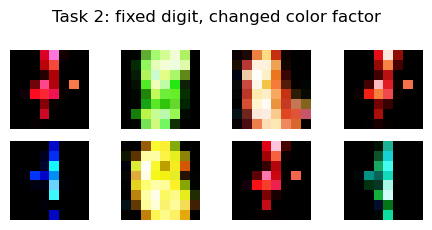

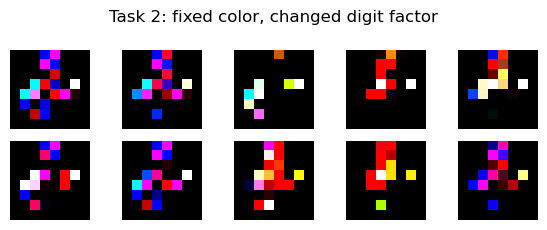

In [8]:
# Task 2.3 TODO (5P)

# Per-class digit-factor prototypes (mean transformed digit factor over the training
# samples of each class). The digit factor is trained as classification *logits*, whose
# learned magnitude is large (~10-25), so a raw 0/1 one-hot is far too weak to move the
# generated digit. The prototypes are the realistic, in-distribution factor values the
# INN actually produces for each digit, which makes the digit edit effective.
with torch.no_grad():
    _digit_train_factor, _, _ = split_factors(iin(z_train_fixed))
    digit_prototypes = torch.stack([_digit_train_factor[y_train_t == d].mean(dim=0) for d in range(10)])

@torch.no_grad()
def change_color_factor(source_index):
    # TODO: keep digit/residual fixed, replace color factor with chosen RGB colors, invert, and decode.
    # Encode the source image's AE latent and split into the learned factors.
    z_src = z_test_fixed[source_index:source_index + 1]
    digit_f, color_f, residual_f = split_factors(iin(z_src))
    # Target foreground colors. Each channel stays in the training range (~[0.35, 1.0])
    # so the injected color factor is in-distribution and the digit stays recognizable.
    palette = to_tensor(np.array([
        [1.0, 0.4, 0.4], [0.4, 1.0, 0.4], [0.4, 0.4, 1.0], [1.0, 1.0, 0.4],
        [1.0, 0.4, 1.0], [0.4, 1.0, 1.0], [1.0, 0.7, 0.4], [1.0, 1.0, 1.0],
    ], dtype=np.float32))
    n = palette.shape[0]
    # Hold digit + residual fixed, swap in each new color, then invert and decode.
    u_new = torch.cat([digit_f.repeat(n, 1), palette, residual_f.repeat(n, 1)], dim=1)
    x_new = ae.decode(iin.inverse(u_new))
    return x_new.detach().cpu().numpy()

@torch.no_grad()
def change_digit_factor(source_index):
    # TODO: keep color/residual fixed, replace digit factor with one-hot digit targets, invert, and decode.
    # (We inject the per-class digit-factor prototypes rather than raw one-hot vectors,
    #  because the digit factor is a high-magnitude logit code; see note above.)
    z_src = z_test_fixed[source_index:source_index + 1]
    digit_f, color_f, residual_f = split_factors(iin(z_src))
    n = digit_prototypes.shape[0]  # one cell per digit 0..9
    # Hold color + residual fixed, swap in each digit prototype, then invert and decode.
    u_new = torch.cat([digit_prototypes, color_f.repeat(n, 1), residual_f.repeat(n, 1)], dim=1)
    x_new = ae.decode(iin.inverse(u_new))
    return x_new.detach().cpu().numpy()

color_edits = change_color_factor(source_index=0)
plot_color_digit_grid(color_edits, "Task 2: fixed digit, changed color factor", nrow=2, ncol=4); plt.show()
digit_edits = change_digit_factor(source_index=0)
plot_color_digit_grid(digit_edits, "Task 2: fixed color, changed digit factor", nrow=2, ncol=5); plt.show()


## Task 3: Conditional Normalizing Flow on Colorized Digits (23P)

Task 2 asked whether an already learned representation can be reorganized into interpretable factors: digit, color, and residual information. Here we use an INN in a different way: as a conditional normalizing flow on the image itself.

```text
x <-> z | y
```

The important new object is the likelihood `p(x | y)`.


In [9]:
# Given: standardize image vectors for the conditional flow
X_mean = X_train_flat.mean(axis=0, keepdims=True)
X_std = X_train_flat.std(axis=0, keepdims=True) + 1e-6
X_train_std = (X_train_flat - X_mean) / X_std
X_test_std = (X_test_flat - X_mean) / X_std
X_train_flow = to_tensor(X_train_std)
X_test_flow = to_tensor(X_test_std)

def decode_flow_x(x_std):
    if isinstance(x_std, torch.Tensor): x_std = x_std.detach().cpu().numpy()
    x = x_std * X_std + X_mean
    return np.clip(x.reshape(-1, 3, 8, 8), 0.0, 1.0)

### Task 3.1: Train the Conditional Flow (6P)

Complete the likelihood loss and training step.

In [10]:
# Given: compact conditional affine-coupling flow
class ConditionalAffineCoupling(nn.Module):
    def __init__(self, dim, cond_dim, hidden_dim, mask):
        super().__init__()
        self.register_buffer("mask", mask.float())
        self.net = nn.Sequential(nn.Linear(dim + cond_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 2 * dim))
    def _st(self, x_masked, cond):
        h = torch.cat([x_masked, cond], dim=1)
        s, t = self.net(h).chunk(2, dim=1)
        inv_mask = 1.0 - self.mask
        return 0.5 * torch.tanh(s) * inv_mask, t * inv_mask
    def forward(self, x, cond, reverse=False):
        x_masked = x * self.mask
        s, t = self._st(x_masked, cond)
        inv_mask = 1.0 - self.mask
        if not reverse:
            y = x_masked + inv_mask * (x * torch.exp(s) + t)
            return y, s.sum(dim=1)
        y = x_masked + inv_mask * ((x - t) * torch.exp(-s))
        return y, -s.sum(dim=1)

class ConditionalINN(nn.Module):
    def __init__(self, dim=DATA_DIM, cond_dim=COND_DIM, hidden_dim=256, n_blocks=6):
        super().__init__()
        layers = []
        for i in range(n_blocks):
            mask = torch.zeros(dim); mask[i % 2 :: 2] = 1.0
            layers.append(ConditionalAffineCoupling(dim, cond_dim, hidden_dim, mask))
        self.layers = nn.ModuleList(layers)
        self.dim = dim
    def forward(self, x, cond):
        total_log_det = torch.zeros(x.shape[0], device=x.device)
        h = x
        for layer in self.layers:
            h, log_det = layer(h, cond, reverse=False); total_log_det += log_det
        return h, total_log_det
    def inverse(self, z, cond):
        total_log_det = torch.zeros(z.shape[0], device=z.device)
        h = z
        for layer in reversed(self.layers):
            h, log_det = layer(h, cond, reverse=True); total_log_det += log_det
        return h, total_log_det

def inverse_error(model, x, cond, n=128):
    model.eval()
    with torch.no_grad():
        x_small = x[:n]; c_small = cond[:n]
        z, _ = model(x_small, c_small); x_rec, _ = model.inverse(z, c_small)
        return (x_small - x_rec).abs().max().item()

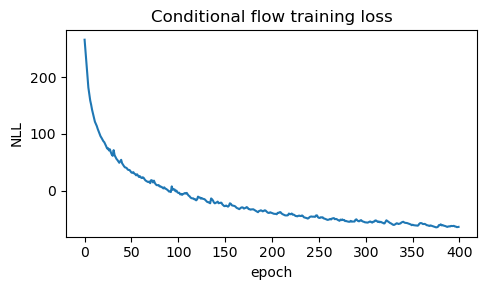

Test NLL: 541.5942993164062
Max inverse error: 1.71661376953125e-05


In [11]:
# Task 3.1 TODO (6P)

cinn = ConditionalINN().to(DEVICE)

def flow_nll_per_sample(z, log_det):
    # Negative log-likelihood of each x under p(x|y), via change of variables:
    #   log p_X(x|y) = log N(z; 0, I) + log|det J_f|,   with z = f(x|y).
    dim = z.shape[1]
    log_pz = -0.5 * (z ** 2).sum(dim=1) - 0.5 * dim * math.log(2.0 * math.pi)
    return -(log_pz + log_det)

def flow_nll(z, log_det):
    # TODO: return the negative log-likelihood of z under a standard Gaussian, plus the log-determinant correction.
    return flow_nll_per_sample(z, log_det).mean()

def train_cinn(model, x, cond, epochs=400, batch_size=256, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    n = x.shape[0]
    model.train()
    for epoch in range(epochs):
        perm = torch.randperm(n, device=x.device)
        epoch_losses = []
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            x_batch = x[idx]
            c_batch = cond[idx]
            # TODO: run model forward, compute flow_nll, and do one optimizer step.
            z, log_det = model(x_batch, c_batch)
            loss = flow_nll(z, log_det)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_losses.append(float(loss.detach().cpu()))
        losses.append(float(np.mean(epoch_losses)))
    return losses

cinn_losses = train_cinn(cinn, X_train_flow, A_train)
plt.figure(figsize=(5, 3)); plt.plot(cinn_losses); plt.xlabel("epoch"); plt.ylabel("NLL"); plt.title("Conditional flow training loss"); plt.tight_layout(); plt.show()

cinn.eval()
with torch.no_grad():
    z_test_flow, log_det_test = cinn(X_test_flow, A_test)
    test_nll = flow_nll(z_test_flow, log_det_test).item()
    max_inv_error = inverse_error(cinn, X_test_flow, A_test)
print("Test NLL:", test_nll)
print("Max inverse error:", max_inv_error)


### Task 3.2: Likelihood Classification (6P)

Evaluate each test image under all ten digit conditions. Predict the digit whose condition gives the lowest NLL. Report the overall accuracy and plot the `10 x 10` confusion matrix.


Likelihood classification accuracy: 0.6955555555555556


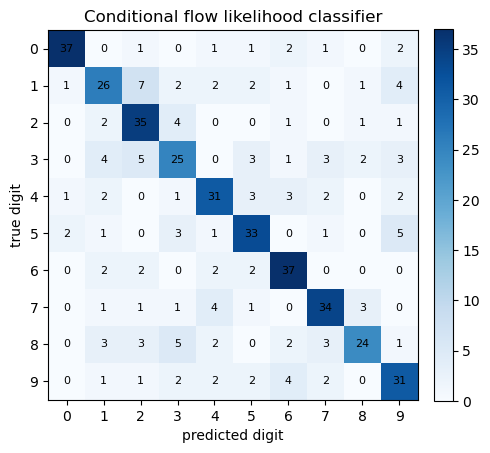

In [12]:
# Task 3.2 TODO (6P)

@torch.no_grad()
def nll_for_all_conditions(model, x_batch):
    model.eval()
    # TODO: return an array of shape (batch_size, 10) with NLL values.
    # For every candidate digit d, run the flow with that one-hot condition and read
    # off the per-sample NLL of x under p(x | y=d). Stacking the 10 columns gives the
    # (batch_size, 10) score matrix; argmin over columns is the likelihood classifier.
    batch_size = x_batch.shape[0]
    columns = []
    for d in range(10):
        cond = to_tensor(one_hot(np.full(batch_size, d, dtype=np.int64)))
        z, log_det = model(x_batch, cond)
        columns.append(flow_nll_per_sample(z, log_det).detach().cpu().numpy())
    return np.stack(columns, axis=1)

nll_matrix = nll_for_all_conditions(cinn, X_test_flow)
pred_labels = nll_matrix.argmin(axis=1)
likelihood_accuracy = accuracy_score(y_test_np, pred_labels)
cm = confusion_matrix(y_test_np, pred_labels, labels=np.arange(10))
print("Likelihood classification accuracy:", likelihood_accuracy)
plot_confusion(cm, "Conditional flow likelihood classifier"); plt.show()


### Task 3.3: Real Digits vs. Random Noise Likelihoods (5P)

Compare the best/lowest NLL of real test digits with random color-noise images using two side-by-side histograms.


Mean best NLL for real digits: 523.4557495117188
Mean best NLL for random noise: 1191298.0


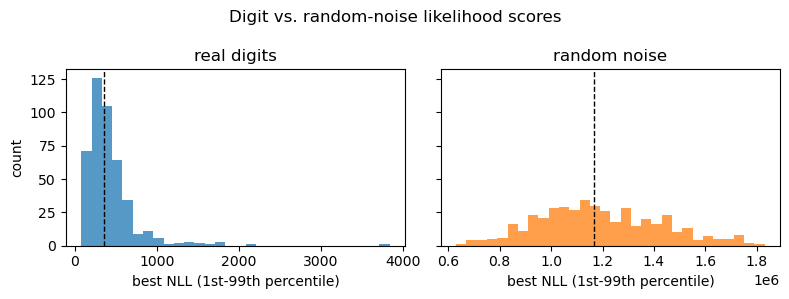

In [13]:
# Task 3.3 TODO (5P)

# TODO: compute the best/lowest NLL over all digit conditions for real and noise images.
# "best" = the most favourable (lowest) NLL the model assigns under any of the 10 digit
# conditions, i.e. min over the condition axis of the (N, 10) NLL matrix.
rng_noise = np.random.default_rng(SEED)
# Random color-noise images in raw pixel space [0, 1], standardized exactly like the data.
noise_pixels = rng_noise.uniform(0.0, 1.0, size=X_test_flat.shape).astype(np.float32)
noise_flow = to_tensor((noise_pixels - X_mean) / X_std)

real_best_nll = nll_for_all_conditions(cinn, X_test_flow).min(axis=1)
noise_best_nll = nll_for_all_conditions(cinn, noise_flow).min(axis=1)

print("Mean best NLL for real digits:", float(np.mean(real_best_nll)))
print("Mean best NLL for random noise:", float(np.mean(noise_best_nll)))

def plot_score_hist(ax, values, title, color):
    lo, hi = np.percentile(values, [1, 99])
    ax.hist(values, bins=30, range=(lo, hi), color=color, alpha=0.75)
    ax.axvline(np.median(values), color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("best NLL (1st-99th percentile)")

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
plot_score_hist(axes[0], real_best_nll, "real digits", "tab:blue")
axes[0].set_ylabel("count")
plot_score_hist(axes[1], noise_best_nll, "random noise", "tab:orange")
fig.suptitle("Digit vs. random-noise likelihood scores")
plt.tight_layout()
plt.show()


### Task 3.4: Conditional Flow Experiments (6P)

Use the inverse direction to inspect the roles of the condition and the latent variable.


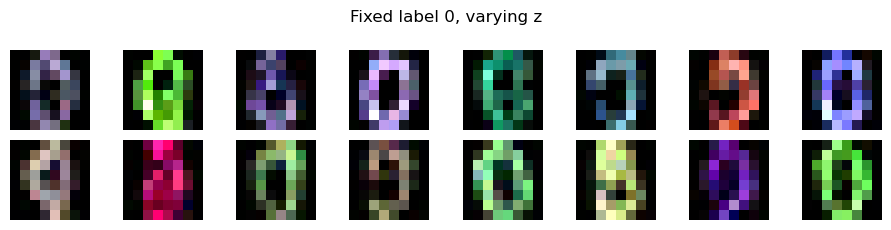

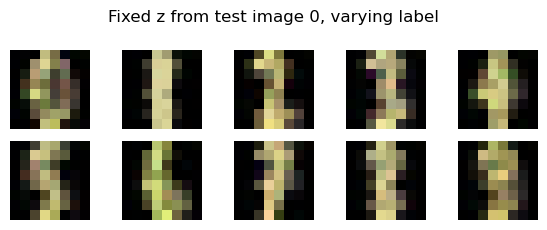

In [14]:
# Task 3.4 TODO (6P)

@torch.no_grad()
def sample_images_for_digit(model, digit, n=16):
    model.eval()
    # TODO: create condition, sample z ~ N(0, I), and run inverse.
    # Fix the label, draw fresh Gaussian latents, and map them back to image space.
    # Varying z at a fixed condition shows the within-class variation the flow captures.
    cond = to_tensor(one_hot(np.full(n, digit, dtype=np.int64)))
    z = torch.randn(n, model.dim, device=DEVICE)
    x, _ = model.inverse(z, cond)
    return x

@torch.no_grad()
def transfer_z_to_all_digits(model, source_index):
    model.eval()
    # TODO: encode one test image to z with its true condition, then decode with all labels.
    # Holding the latent z fixed and only swapping the condition shows what the label
    # controls vs. what z (style/colour) carries.
    x_src = X_test_flow[source_index:source_index + 1]
    c_src = A_test[source_index:source_index + 1]
    z, _ = model(x_src, c_src)
    z_rep = z.repeat(10, 1)
    conds = to_tensor(one_hot(np.arange(10)))
    x_all, _ = model.inverse(z_rep, conds)
    return x_all

x_samples = sample_images_for_digit(cinn, digit=0, n=16)
plot_color_digit_grid(decode_flow_x(x_samples), "Fixed label 0, varying z", nrow=2, ncol=8); plt.show()
source_index = 0
x_transfer = transfer_z_to_all_digits(cinn, source_index)
plot_color_digit_grid(decode_flow_x(x_transfer), f"Fixed z from test image {source_index}, varying label", nrow=2, ncol=5); plt.show()
